## Forecaster
Re-optimizes indicator weights against forward SPY drawdown labels (lookahead=60 days),
then trains a logistic regression classifier to output drawdown probability.
Uses `TimeSeriesSplit(gap=LOOKAHEAD)` throughout to prevent forward label leakage.

In [1]:
import os
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import TimeSeriesSplit

N_JOBS = os.cpu_count()
print(f"using {N_JOBS} cores")

using 20 cores


### 1. Load data

In [2]:
try:
    df = pd.read_parquet("data/processed/stress_score.parquet")
    DOCS_PATH = Path("docs")
except FileNotFoundError:
    df = pd.read_parquet("../data/processed/stress_score.parquet")
    DOCS_PATH = Path("../docs")

df.index = pd.to_datetime(df.index)

INDICATOR_COLS = [
    "T10Y2Y",
    "T10Y3M",
    "T30Y10Y",
    "USALOLITOAASTSAM",
    "UMCSENT",
    "PERMIT",
    "NEWORDER",
    "ICSA",
    "DRCCLACBS",
    "BAMLH0A0HYM2",
    "XLK_XLV",
    "TLT",
    "HG=F",
    "CL=F",
    "EEM",
    "DX-Y.NYB",
]

df = df.dropna(subset=INDICATOR_COLS)
print(f"{len(df)} rows, {df.index[0].date()} to {df.index[-1].date()}")

5020 rows, 2006-04-26 to 2026-03-25


### 2. Forward drawdown labels
Label is 1 if SPY drops >= 10% at any point within the next `LOOKAHEAD` trading days.
The last `LOOKAHEAD` rows are dropped — no complete forward window is available there.

In [3]:
for threshold in [0.05, 0.08, 0.10]:
    for lookahead in [20, 40, 60, 90, 120]:
        spy = df["SPY"]
        future_min = (
            spy[::-1]
            .rolling(window=lookahead, min_periods=lookahead)
            .min()[::-1]
            .shift(-1)
        )
        future_drop = future_min / spy - 1
        y = (future_drop <= -threshold).astype(int)
        y = y.dropna()
        print(
            f"threshold={threshold:.0%} lookahead={lookahead}d: {y.mean():.1%} positive"
        )

threshold=5% lookahead=20d: 17.1% positive
threshold=5% lookahead=40d: 26.3% positive
threshold=5% lookahead=60d: 31.6% positive
threshold=5% lookahead=90d: 36.2% positive
threshold=5% lookahead=120d: 39.9% positive
threshold=8% lookahead=20d: 7.3% positive
threshold=8% lookahead=40d: 14.0% positive
threshold=8% lookahead=60d: 18.6% positive
threshold=8% lookahead=90d: 23.4% positive
threshold=8% lookahead=120d: 27.8% positive
threshold=10% lookahead=20d: 4.3% positive
threshold=10% lookahead=40d: 9.6% positive
threshold=10% lookahead=60d: 14.2% positive
threshold=10% lookahead=90d: 19.3% positive
threshold=10% lookahead=120d: 22.7% positive


In [4]:
DRAWDOWN_THRESHOLD = 0.08
LOOKAHEAD = 90

spy = df["SPY"]

# future_min[t] = min(spy[t+1], ..., spy[t+LOOKAHEAD])
future_min = (
    spy[::-1].rolling(window=LOOKAHEAD, min_periods=LOOKAHEAD).min()[::-1].shift(-1)
)
future_drop = future_min / spy - 1

labels_fwd = pd.Series(np.nan, index=spy.index)
valid = future_min.notna()
labels_fwd[valid] = (future_drop[valid] <= -DRAWDOWN_THRESHOLD).astype(float)

labels_fwd = labels_fwd.dropna().astype(int)

print(
    f"forward drawdown events: {labels_fwd.sum()} of {len(labels_fwd)} ({labels_fwd.mean():.1%})"
)
print(f"dropped last {LOOKAHEAD} rows (no complete forward window)")

forward drawdown events: 1177 of 4930 (23.9%)
dropped last 90 rows (no complete forward window)


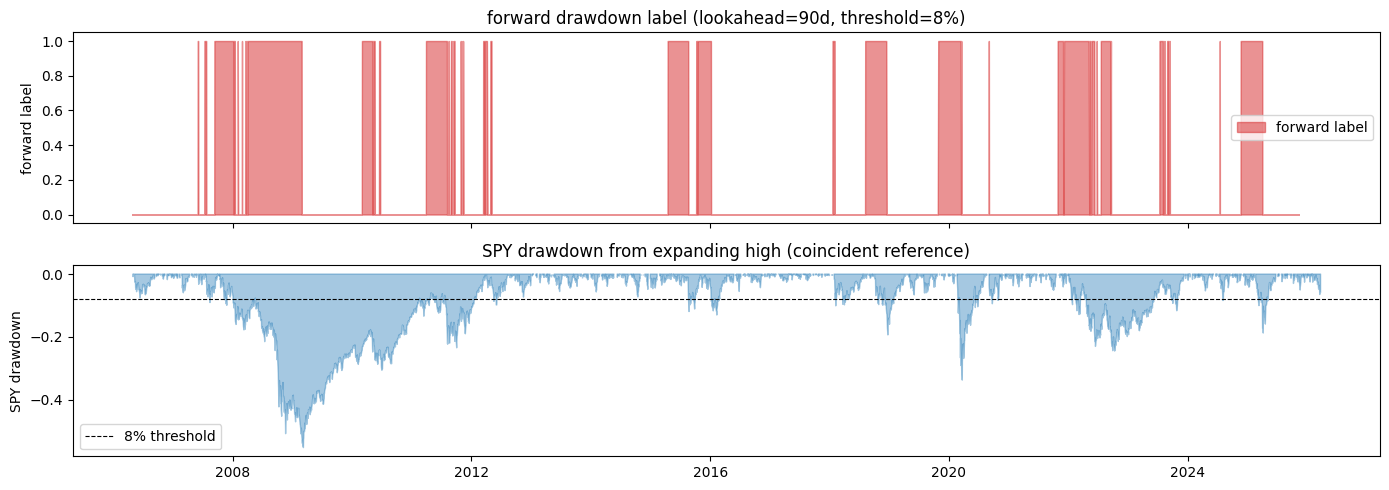

In [5]:
coincident_dd = spy / spy.cummax() - 1
coincident_labels = (coincident_dd <= -DRAWDOWN_THRESHOLD).astype(int)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].fill_between(
    labels_fwd.index, labels_fwd, alpha=0.5, color="#d62728", label="forward label"
)
axes[0].set_ylabel("forward label")
axes[0].set_title(
    f"forward drawdown label (lookahead={LOOKAHEAD}d, threshold={DRAWDOWN_THRESHOLD:.0%})"
)
axes[0].legend()

axes[1].fill_between(
    coincident_dd.index,
    coincident_dd,
    0,
    where=coincident_dd < 0,
    alpha=0.4,
    color="#1f77b4",
)
axes[1].axhline(
    -DRAWDOWN_THRESHOLD,
    color="black",
    linewidth=0.8,
    linestyle="--",
    label=f"{DRAWDOWN_THRESHOLD:.0%} threshold",
)
axes[1].set_ylabel("SPY drawdown")
axes[1].set_title("SPY drawdown from expanding high (coincident reference)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3. Optimization functions
Same SLSQP setup as `weight_optimizer.ipynb`. The only change is that labels are forward-shifted,
so the optimizer learns weights that predict future drawdowns rather than confirming current ones.

In [6]:
N = len(INDICATOR_COLS)
EQUAL_WEIGHTS = np.ones(N) / N
BOUNDS = [(-0.10, 0.25)] * N
SUM_TO_ONE = [{"type": "eq", "fun": lambda w: w.sum() - 1}]


def soft_auc(weights, X, y):
    score = (X * weights).sum(axis=1)
    pos = score[y == 1].values
    neg = score[y == 0].values
    diff = pos[:, None] - neg[None, :]
    return -np.mean(1 / (1 + np.exp(-diff * 10)))


def fit_slsqp(X_train, y_train, alpha=0.0):
    def objective(weights):
        reg = alpha * ((weights - EQUAL_WEIGHTS) ** 2).sum()
        return soft_auc(weights, X_train, y_train) + reg

    result = minimize(
        objective,
        EQUAL_WEIGHTS,
        method="SLSQP",
        bounds=BOUNDS,
        constraints=SUM_TO_ONE,
        options={"ftol": 1e-9, "maxiter": 1000},
    )
    return result.x

### 4. CV helper
`TimeSeriesSplit(gap=LOOKAHEAD)` skips `LOOKAHEAD` samples between each train and test fold.
Without the gap, some training labels' forward windows overlap with the test period.

In [7]:
def run_cv(fit_fn, alpha=0.0, n_splits=5, gap=LOOKAHEAD, X=None, y=None):
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    folds = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if y_test.nunique() < 2 or y_train.nunique() < 2:
            continue

        weights = fit_fn(X_train, y_train, alpha=alpha)
        train_auc = roc_auc_score(y_train, (X_train * weights).sum(axis=1))
        test_auc = roc_auc_score(y_test, (X_test * weights).sum(axis=1))

        folds.append(
            {
                "fold": fold + 1,
                "train_size": len(train_idx),
                "test_size": len(test_idx),
                "test_start": X.index[test_idx[0]].date(),
                "test_end": X.index[test_idx[-1]].date(),
                "train_auc": train_auc,
                "test_auc": test_auc,
                "gap": train_auc - test_auc,
                "weights": weights,
            }
        )

    return folds


def summarize(folds, label):
    test_aucs = [f["test_auc"] for f in folds]
    gaps = [f["gap"] for f in folds]
    print(
        f"{label:16s}  test AUC: {np.mean(test_aucs):.4f} +/- {np.std(test_aucs):.4f}"
        f"  gap: {np.mean(gaps):.4f} +/- {np.std(gaps):.4f}"
    )

### 5. Baseline CV (equal weights against forward labels)

In [8]:
X_data = df.loc[labels_fwd.index, INDICATOR_COLS]
y_data = labels_fwd


def fit_equal(X_train, y_train, alpha=0.0):
    return EQUAL_WEIGHTS


folds_equal = run_cv(fit_equal, X=X_data, y=y_data)

print("fold sizes:")
for f in folds_equal:
    print(
        f"  fold {f['fold']}: train={f['train_size']}  test={f['test_size']}"
        f"  ({f['test_start']} to {f['test_end']})"
    )
print()

folds_slsqp = run_cv(fit_slsqp, alpha=0.0, X=X_data, y=y_data)

summarize(folds_equal, "equal")
summarize(folds_slsqp, "slsqp (a=0)")

fold sizes:
  fold 1: train=735  test=821  (2009-07-29 to 2012-10-26)
  fold 2: train=1556  test=821  (2012-10-31 to 2016-02-03)
  fold 3: train=2377  test=821  (2016-02-04 to 2019-05-09)
  fold 4: train=3198  test=821  (2019-05-10 to 2022-08-11)
  fold 5: train=4019  test=821  (2022-08-12 to 2025-11-12)

equal             test AUC: 0.5258 +/- 0.2147  gap: 0.0994 +/- 0.2636
slsqp (a=0)       test AUC: 0.5149 +/- 0.1941  gap: 0.3055 +/- 0.2275


### 6. Alpha sweep

In [9]:
ALPHAS = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.5, 10.0]


def _sweep_job(alpha, X, y):
    folds = run_cv(fit_slsqp, alpha=alpha, X=X, y=y)
    return {
        "alpha": alpha,
        "mean_test_auc": np.mean([f["test_auc"] for f in folds]),
        "mean_gap": np.mean([f["gap"] for f in folds]),
        "std_test_auc": np.std([f["test_auc"] for f in folds]),
    }


sweep_raw = Parallel(n_jobs=N_JOBS)(
    delayed(_sweep_job)(alpha, X_data, y_data) for alpha in ALPHAS
)

sweep_results = sorted(sweep_raw, key=lambda r: r["alpha"])
print("sweep complete")

sweep complete


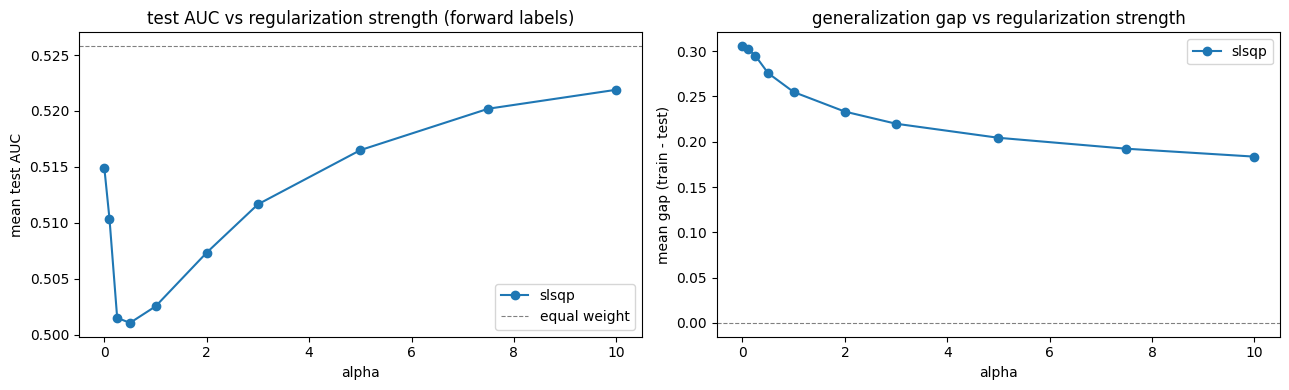

In [10]:
alphas = [r["alpha"] for r in sweep_results]
test_aucs = [r["mean_test_auc"] for r in sweep_results]
gaps = [r["mean_gap"] for r in sweep_results]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(alphas, test_aucs, "o-", color="#1f77b4", label="slsqp")
axes[0].axhline(
    np.mean([f["test_auc"] for f in folds_equal]),
    color="grey",
    linewidth=0.8,
    linestyle="--",
    label="equal weight",
)
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("mean test AUC")
axes[0].set_title("test AUC vs regularization strength (forward labels)")
axes[0].legend()

axes[1].plot(alphas, gaps, "o-", color="#1f77b4", label="slsqp")
axes[1].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("mean gap (train - test)")
axes[1].set_title("generalization gap vs regularization strength")
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
best = max(sweep_results, key=lambda r: r["mean_test_auc"] - abs(r["mean_gap"]))
print(
    f"best alpha={best['alpha']:.2f}  test AUC={best['mean_test_auc']:.4f}  gap={best['mean_gap']:.4f}"
)

best alpha=10.00  test AUC=0.5219  gap=0.1835


### 7. Final CV with best alpha + weight stability

In [12]:
BEST_ALPHA = best["alpha"]
print(f"best alpha: {BEST_ALPHA}  (test AUC {best['mean_test_auc']:.4f})")

folds_slsqp_reg = run_cv(fit_slsqp, alpha=BEST_ALPHA, X=X_data, y=y_data)

print("final CV results:")
summarize(folds_equal, "equal")
summarize(folds_slsqp_reg, f"slsqp a={BEST_ALPHA}")

best alpha: 10.0  (test AUC 0.5219)
final CV results:
equal             test AUC: 0.5258 +/- 0.2147  gap: 0.0994 +/- 0.2636
slsqp a=10.0      test AUC: 0.5219 +/- 0.2113  gap: 0.1835 +/- 0.2823


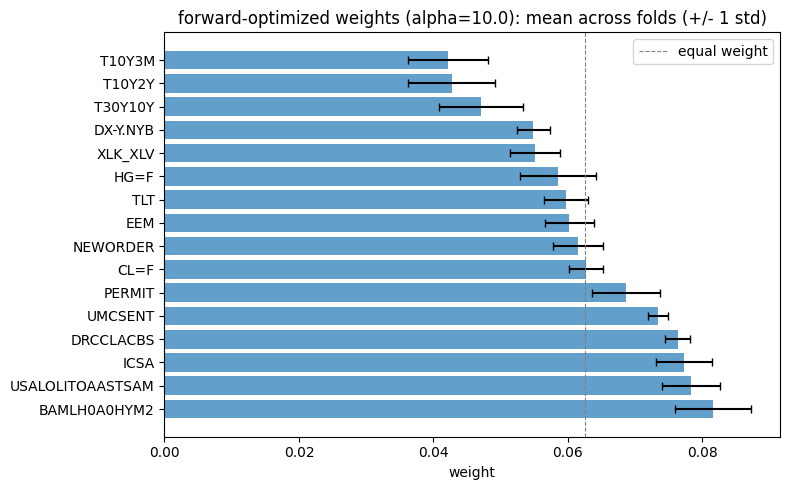

In [13]:
weights_per_fold = np.vstack([f["weights"] for f in folds_slsqp_reg])
mean_w = weights_per_fold.mean(axis=0)
std_w = weights_per_fold.std(axis=0)
order = np.argsort(mean_w)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    np.array(INDICATOR_COLS)[order],
    mean_w[order],
    xerr=std_w[order],
    color="#1f77b4",
    alpha=0.7,
    capsize=3,
)
ax.axvline(1 / N, color="grey", linewidth=0.8, linestyle="--", label="equal weight")
ax.set_title(
    f"forward-optimized weights (alpha={BEST_ALPHA}): mean across folds (+/- 1 std)"
)
ax.set_xlabel("weight")
ax.legend()
plt.tight_layout()
plt.show()

### 8. Classifier
Logistic regression on the 16 indicator features with `TimeSeriesSplit(gap=LOOKAHEAD)`.
AUC and Brier score per fold; final model trained on full dataset.

In [14]:
tscv = TimeSeriesSplit(n_splits=5, gap=LOOKAHEAD)
clf_folds = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_data)):
    X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
    y_train, y_test = y_data.iloc[train_idx], y_data.iloc[test_idx]

    if y_train.nunique() < 2 or y_test.nunique() < 2:
        continue

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    clf_folds.append(
        {
            "fold": fold + 1,
            "test_start": X_data.index[test_idx[0]].date(),
            "test_end": X_data.index[test_idx[-1]].date(),
            "auc": roc_auc_score(y_test, proba),
            "brier": brier_score_loss(y_test, proba),
        }
    )

print("classifier CV results:")
for f in clf_folds:
    print(
        f"  fold {f['fold']} ({f['test_start']} to {f['test_end']}):  AUC={f['auc']:.4f}  Brier={f['brier']:.4f}"
    )

print()
print(f"mean AUC:   {np.mean([f['auc'] for f in clf_folds]):.4f}")
print(f"mean Brier: {np.mean([f['brier'] for f in clf_folds]):.4f}")

classifier CV results:
  fold 1 (2009-07-29 to 2012-10-26):  AUC=0.4926  Brier=0.2932
  fold 2 (2012-10-31 to 2016-02-03):  AUC=0.3945  Brier=0.3946
  fold 3 (2016-02-04 to 2019-05-09):  AUC=0.1341  Brier=0.1831
  fold 4 (2019-05-10 to 2022-08-11):  AUC=0.7059  Brier=0.2289
  fold 5 (2022-08-12 to 2025-11-12):  AUC=0.4976  Brier=0.2276

mean AUC:   0.4449
mean Brier: 0.2655


In [15]:
# baseline Brier: equal-weight score isn't a probability, but serves as a rank-based reference
equal_score = X_data.sum(axis=1) / N

baseline_aucs, baseline_briers = [], []
for _, test_idx in TimeSeriesSplit(n_splits=5, gap=LOOKAHEAD).split(X_data):
    y_test = y_data.iloc[test_idx]
    eq_test = equal_score.iloc[test_idx]
    if y_test.nunique() < 2:
        continue
    baseline_aucs.append(roc_auc_score(y_test, eq_test))
    baseline_briers.append(brier_score_loss(y_test, eq_test))

print("baseline (equal-weight score):")
print(f"  mean AUC:   {np.mean(baseline_aucs):.4f}")
print(f"  mean Brier: {np.mean(baseline_briers):.4f}")

baseline (equal-weight score):
  mean AUC:   0.5258
  mean Brier: 0.2372


### 9. Final model and probability visualization

In [16]:
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_data, y_data)
drawdown_prob = pd.Series(final_model.predict_proba(X_data)[:, 1], index=X_data.index)

final_weights = fit_slsqp(X_data, y_data, alpha=BEST_ALPHA)
forecast_score = (X_data * final_weights).sum(axis=1)

print("in-sample AUC (full data, for reference only):")
print(f"  equal weight:    {roc_auc_score(y_data, equal_score):.4f}")
print(f"  forecast score:  {roc_auc_score(y_data, forecast_score):.4f}")
print(f"  classifier:      {roc_auc_score(y_data, drawdown_prob):.4f}")

in-sample AUC (full data, for reference only):
  equal weight:    0.5588
  forecast score:  0.5861
  classifier:      0.8136


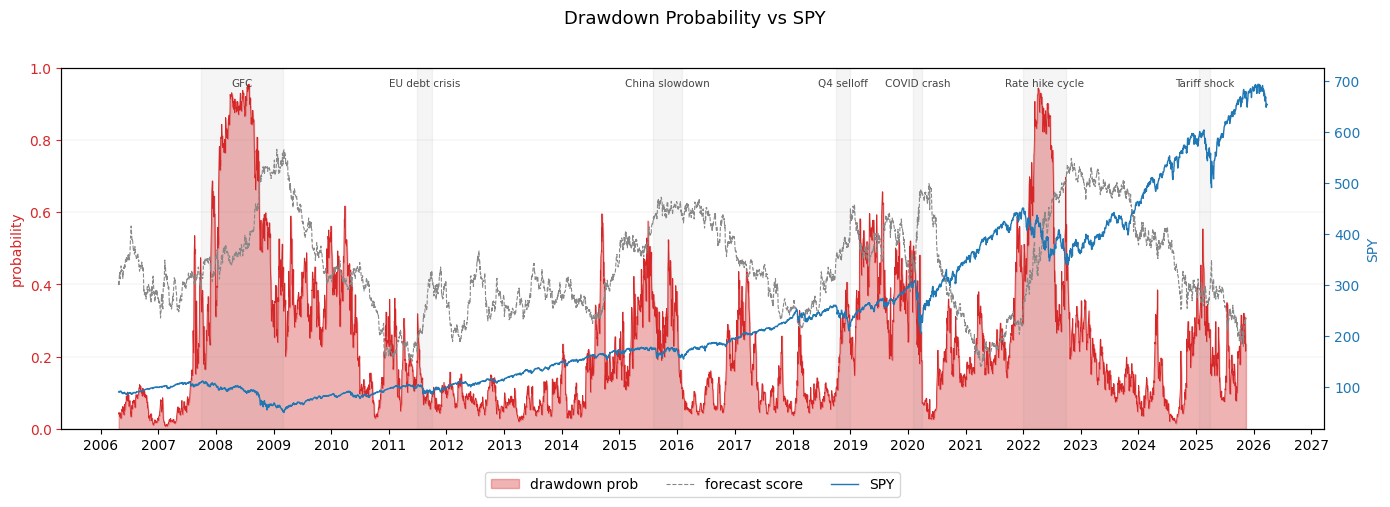

In [17]:
STRESS_PERIODS = [
    ("2007-10-01", "2009-03-01", "GFC"),
    ("2011-07-01", "2011-10-01", "EU debt crisis"),
    ("2015-08-01", "2016-02-01", "China slowdown"),
    ("2018-10-01", "2018-12-31", "Q4 selloff"),
    ("2020-02-01", "2020-04-01", "COVID crash"),
    ("2022-01-01", "2022-10-01", "Rate hike cycle"),
    ("2025-01-20", "2025-04-01", "Tariff shock"),
]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(
    drawdown_prob.index,
    drawdown_prob,
    alpha=0.35,
    color="#d62728",
    label="drawdown prob",
)
ax1.plot(drawdown_prob.index, drawdown_prob, color="#d62728", linewidth=0.6)
ax1.plot(
    forecast_score.index,
    forecast_score,
    color="#888888",
    linewidth=0.8,
    linestyle="--",
    label="forecast score",
)
ax2.plot(df.index, df["SPY"], color="#1f77b4", linewidth=1.0, label="SPY")

for start, end, label in STRESS_PERIODS:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color="grey")
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax1.text(
        mid,
        0.97,
        label,
        ha="center",
        va="top",
        fontsize=7.5,
        color="#444444",
        transform=ax1.get_xaxis_transform(),
    )

ax1.set_ylabel("probability", color="#d62728")
ax2.set_ylabel("SPY", color="#1f77b4")
ax1.set_ylim(0, 1)
ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.yaxis.grid(True, linewidth=0.3, color="grey", alpha=0.25)
ax1.set_axisbelow(True)
ax2.yaxis.grid(False)
ax1.tick_params(axis="y", colors="#d62728")
ax2.tick_params(axis="y", colors="#1f77b4")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator())

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)

fig.suptitle("Drawdown Probability vs SPY", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

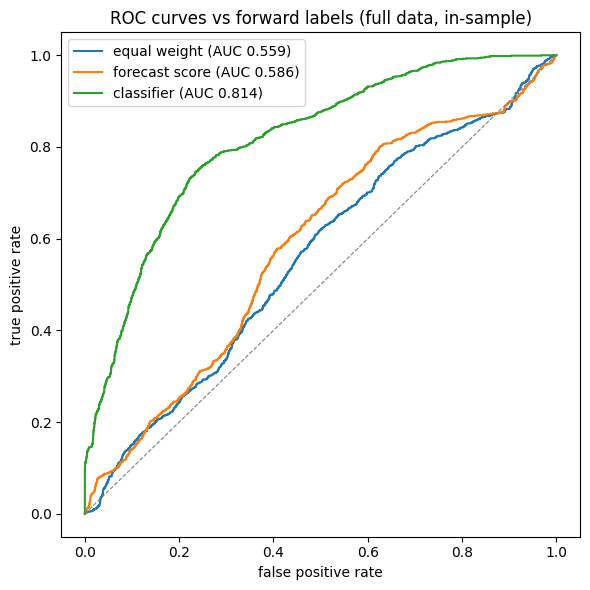

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))

for score, label, color in [
    (
        equal_score,
        f"equal weight (AUC {roc_auc_score(y_data, equal_score):.3f})",
        "#aec7e8",
    ),
    (
        forecast_score,
        f"forecast score (AUC {roc_auc_score(y_data, forecast_score):.3f})",
        "#aaaaaa",
    ),
    (
        drawdown_prob,
        f"classifier (AUC {roc_auc_score(y_data, drawdown_prob):.3f})",
        "#d62728",
    ),
]:
    fpr, tpr, _ = roc_curve(y_data, score)
    ax.plot(fpr, tpr, label=label)

ax.plot([0, 1], [0, 1], color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curves vs forward labels (full data, in-sample)")
ax.legend()
plt.tight_layout()
plt.show()